<a href="https://colab.research.google.com/github/RyanW1610/TMS-Shipment-Delay-Prediction/blob/main/Wilson_Ryan_Amazon_Food_Review_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Amazon Food Review Sentiment Analysis

**Author:** Ryan Wilson

**Dataset:** Amazon Fine Food Reviews (Kaggle)

## Project Overview

This project uses natural language processing (NLP) and machine learning to classify Amazon food reviews as positive or negative. The project compares several machine learning and deep learning models to determine which provides the best performance.

## Tools Used

- Python
- Google Colab
- Pandas
- Scikit-learn
- TensorFlow / Keras
- Matplotlib
- KaggleHub

## 1. Dataset Acquisition

The dataset was downloaded from Kaggle using KaggleHub. It contains Amazon customer food reviews, review scores, and review text used for sentiment analysis.

In [16]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("snap/amazon-fine-food-reviews")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'amazon-fine-food-reviews' dataset.
Path to dataset files: /kaggle/input/amazon-fine-food-reviews


In [17]:
import pandas as parse_dataset_handle
import os

df = parse_dataset_handle.read_csv(os.path.join(path, 'Reviews.csv'), nrows=10000)
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


## 2. Data Exploration

The dataset was explored by checking the number of records, available columns, and missing values before preprocessing.

In [18]:
df.shape

(10000, 10)

In [19]:
df.columns

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')

In [20]:
df.isnull().sum()

,0
Id,0
ProductId,0
UserId,0
ProfileName,0
HelpfulnessNumerator,0
HelpfulnessDenominator,0
Score,0
Time,0
Summary,0
Text,0


## 3. Data Preprocessing

The review scores were converted into sentiment labels.

- Scores 1–2 = Negative
- Scores 4–5 = Positive
- Score 3 = Removed as Neutral

In [21]:
df = df[['Score', 'Text']]

def sentiment(score):
    if score <= 2:
        return 0   # negative
    elif score >= 4:
        return 1   # positive
    else:
        return None  # drop neutral

df['Sentiment'] = df['Score'].apply(sentiment)

# Drop neutral (3-star reviews)
df = df.dropna()

df.head()

,Score,Text,Sentiment
0,5,I have bought several of the Vitality canned d...,1.0
1,1,Product arrived labeled as Jumbo Salted Peanut...,0.0
2,4,This is a confection that has been around a fe...,1.0
3,2,If you are looking for the secret ingredient i...,0.0
4,5,Great taffy at a great price. There was a wid...,1.0


## 4. Feature Engineering

The review text was converted into numerical features using TF-IDF Vectorization before training the machine learning models.

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Split FIRST
X = df['Text']   # use 'Text' column as 'cleaned_text' is not present
y = df['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2. Vectorize AFTER split
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"Train shape: {X_train_tfidf.shape}")
print(f"Test shape: {X_test_tfidf.shape}")

Train shape: (7310, 5000)
Test shape: (1828, 5000)


## 5. Logistic Regression Model

A Logistic Regression classifier was trained as the baseline machine learning model.

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Initialize and train
model_lr = LogisticRegression()
model_lr.fit(X_train_tfidf, y_train)

# Make predictions
predictions = model_lr.predict(X_test_tfidf)

# Check how you did
print(f"Accuracy: {accuracy_score(y_test, predictions)}")
print(classification_report(y_test, predictions))

Accuracy: 0.8834792122538293
              precision    recall  f1-score   support

         0.0       0.90      0.28      0.42       282
         1.0       0.88      0.99      0.94      1546

    accuracy                           0.88      1828
   macro avg       0.89      0.64      0.68      1828
weighted avg       0.88      0.88      0.86      1828



## 6. Balanced Logistic Regression

A balanced Logistic Regression model was trained to better handle class imbalance within the dataset.

In [24]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(class_weight='balanced')
model_lr.fit(X_train_tfidf, y_train)

predictions = model_lr.predict(X_test_tfidf)

print("Balanced Accuracy:", accuracy_score(y_test, predictions))
print(classification_report(y_test, predictions))

Balanced Accuracy: 0.8829321663019694
              precision    recall  f1-score   support

         0.0       0.59      0.81      0.68       282
         1.0       0.96      0.90      0.93      1546

    accuracy                           0.88      1828
   macro avg       0.78      0.85      0.80      1828
weighted avg       0.91      0.88      0.89      1828



## 7. Random Forest Model

A Random Forest classifier was trained and evaluated. A sample decision tree from the forest was also visualized.

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

model_rf = RandomForestClassifier(n_estimators=50, n_jobs=-1, verbose=2, random_state=42)

model_rf.fit(X_train_tfidf, y_train)

rf_preds = model_rf.predict(X_test_tfidf)

print(f"Random Forest Accuracy: {accuracy_score(y_test, rf_preds)}")
print(classification_report(y_test, rf_preds))

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.


building tree 1 of 50
building tree 2 of 50
building tree 3 of 50
building tree 4 of 50
building tree 5 of 50
building tree 6 of 50
building tree 7 of 50
building tree 8 of 50
building tree 9 of 50
building tree 10 of 50
building tree 11 of 50
building tree 12 of 50
building tree 13 of 50
building tree 14 of 50
building tree 15 of 50
building tree 16 of 50
building tree 17 of 50
building tree 18 of 50
building tree 19 of 50
building tree 20 of 50
building tree 21 of 50
building tree 22 of 50
building tree 23 of 50
building tree 24 of 50
building tree 25 of 50
building tree 26 of 50
building tree 27 of 50
building tree 28 of 50
building tree 29 of 50
building tree 30 of 50
building tree 31 of 50
building tree 32 of 50
building tree 33 of 50
building tree 34 of 50
building tree 35 of 50
building tree 36 of 50
building tree 37 of 50
building tree 38 of 50
building tree 39 of 50
building tree 40 of 50


[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:    2.9s


building tree 41 of 50building tree 42 of 50

building tree 43 of 50
building tree 44 of 50
building tree 45 of 50
building tree 46 of 50
building tree 47 of 50
building tree 48 of 50
building tree 49 of 50
building tree 50 of 50
Random Forest Accuracy: 0.8900437636761488
              precision    recall  f1-score   support

         0.0       0.87      0.34      0.49       282
         1.0       0.89      0.99      0.94      1546

    accuracy                           0.89      1828
   macro avg       0.88      0.66      0.71      1828
weighted avg       0.89      0.89      0.87      1828



[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:    3.5s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done  50 out of  50 | elapsed:    0.0s finished


## 8. Decision Tree Visualization

A sample decision tree from the Random Forest model was visualized to better understand how the model makes predictions. The tree shows how important words are used to split the data into positive and negative sentiment classifications.

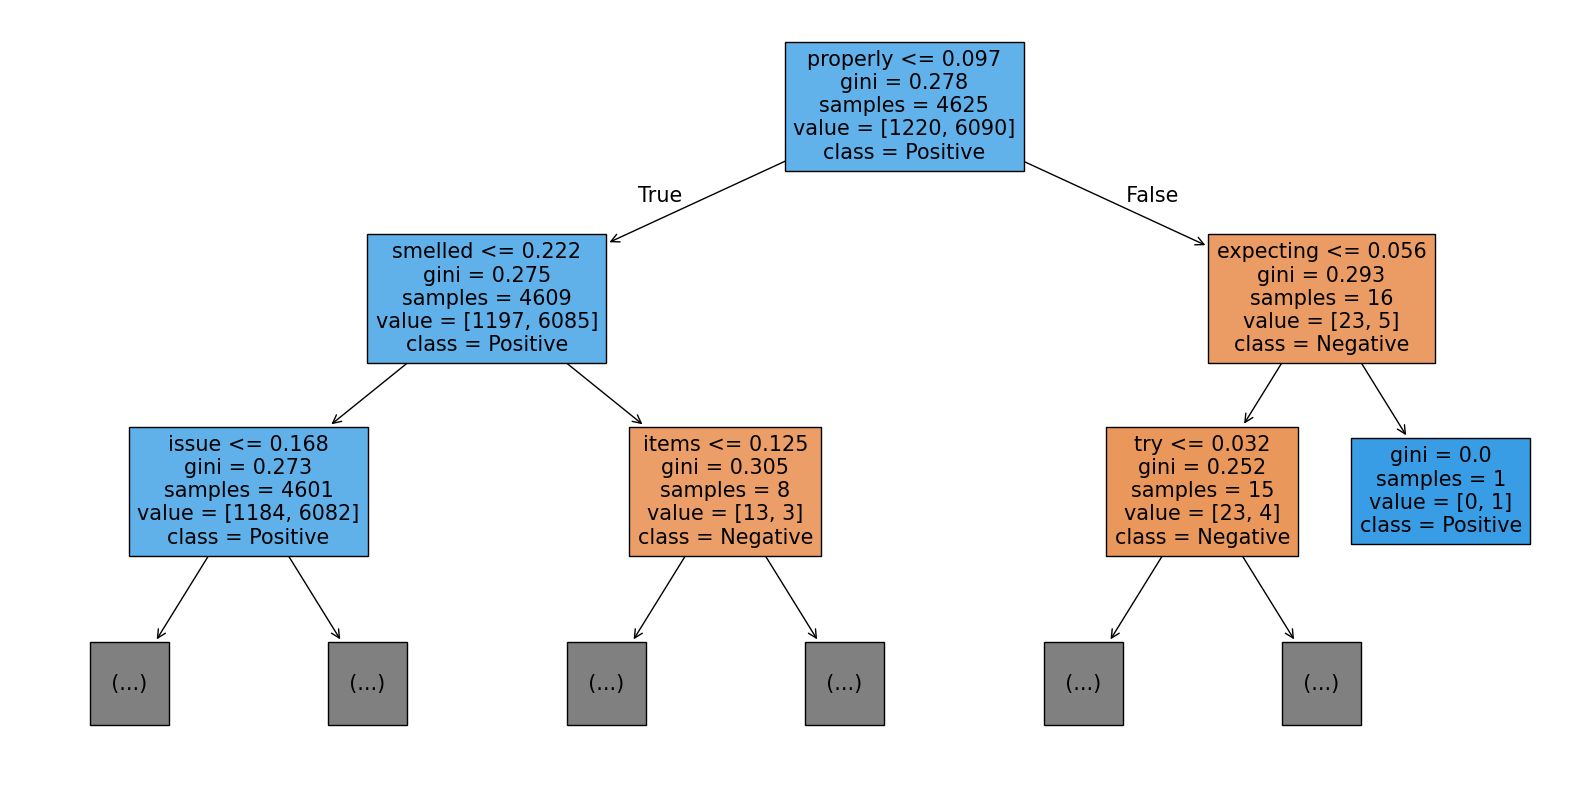

In [26]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Pick one tree from your forest (let's pick the first one, index 0)
chosen_tree = model_rf.estimators_[0]

# Plot it
plt.figure(figsize=(20,10))
plot_tree(chosen_tree,
          max_depth=2, # We limit depth so it doesn't get too messy
          feature_names=tfidf.get_feature_names_out(),
          class_names=['Negative', 'Positive'],
          filled=True)
plt.show()


## 9. Support Vector Machine (SVM) Results

This section trains and evaluates the Support Vector Machine (SVM) model. The model's performance is measured using accuracy, precision, recall, and F1-score to compare it with the other classification models.

In [27]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

model_svm = LinearSVC(random_state=42)

model_svm.fit(X_train_tfidf, y_train)

svm_preds = model_svm.predict(X_test_tfidf)

print("Support Vector Machine (SVM) Results")
print("Accuracy:", round(accuracy_score(y_test, svm_preds), 3))
print(classification_report(y_test, svm_preds, target_names=['Negative', 'Positive']))

Support Vector Machine (SVM) Results
Accuracy: 0.914
              precision    recall  f1-score   support

    Negative       0.78      0.62      0.69       282
    Positive       0.93      0.97      0.95      1546

    accuracy                           0.91      1828
   macro avg       0.86      0.79      0.82      1828
weighted avg       0.91      0.91      0.91      1828



## 10. Deep Learning Data Preparation

The text data was prepared for deep learning models by tokenizing the reviews, converting them into sequences, and padding the sequences to create a consistent input length for the neural network models.

In [28]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers

# 1. Split text and labels first
X = df['Text']
y = df['Sentiment'].values

X_train_text, X_test_text, y_train_dl, y_test_dl = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2. Fit tokenizer ONLY on training text
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X_train_text)

# 3. Convert train and test text separately
X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

# 4. Pad train and test separately
X_train_dl = pad_sequences(X_train_seq, maxlen=100)
X_test_dl = pad_sequences(X_test_seq, maxlen=100)

print("Deep learning data ready")
print("Train shape:", X_train_dl.shape)
print("Test shape:", X_test_dl.shape)

Deep learning data ready
Train shape: (7310, 100)
Test shape: (1828, 100)


In [29]:
X_train_dl, y_train_dl
X_test_dl, y_test_dl

(array([[   0,    0,    0, ..., 2420,   23,  585],
        [   0,    0,    0, ...,   14,   33,  385],
        [ 305,  235,   12, ...,   85,    2,  678],
        ...,
        [   0,    0,    0, ...,   94,   13,  297],
        [   0,    0,    0, ...,   46,  100,   24],
        [   0,    0,    0, ...,   48,   61, 3863]], dtype=int32),
 array([1., 0., 1., ..., 1., 0., 1.]))

## 11. Basic Neural Network

A simple feedforward neural network was built using TensorFlow and Keras for sentiment classification.

In [30]:

model_v1 = tf.keras.Sequential([
    layers.Embedding(input_dim=5000, output_dim=16),
    layers.GlobalAveragePooling1D(),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model_v1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Training Basic Neural Network...")

history_nn = model_v1.fit(
    X_train_dl,
    y_train_dl,
    epochs=5,
    batch_size=32,
    validation_data=(X_test_dl, y_test_dl)
)

Training Basic Neural Network...
Epoch 1/5
229/229 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8298 - loss: 0.4744 - val_accuracy: 0.8457 - val_loss: 0.4215
Epoch 2/5
229/229 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8304 - loss: 0.4316 - val_accuracy: 0.8457 - val_loss: 0.4048
Epoch 3/5
229/229 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8306 - loss: 0.4001 - val_accuracy: 0.8468 - val_loss: 0.3659
Epoch 4/5
229/229 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8471 - loss: 0.3361 - val_accuracy: 0.8638 - val_loss: 0.3080
Epoch 5/5
229/229 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8848 - loss: 0.2706 - val_accuracy: 0.8900 - val_loss: 0.2718


In [31]:
loss, accuracy = model_v1.evaluate(X_test_dl, y_test_dl)
print("Basic Neural Network Accuracy:", accuracy)

58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8900 - loss: 0.2718
Basic Neural Network Accuracy: 0.8900437355041504


## 12. Long Short-Term Memory (LSTM)

An LSTM deep learning model was trained to capture sequential relationships within the review text.

In [32]:

model_lstm = tf.keras.Sequential([
    layers.Embedding(input_dim=5000, output_dim=16),
    layers.LSTM(32),
    layers.Dense(1, activation='sigmoid')
])

model_lstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Training LSTM Model...")

history_lstm = model_lstm.fit(
    X_train_dl,
    y_train_dl,
    epochs=5,
    batch_size=64,
    validation_data=(X_test_dl, y_test_dl)
)

loss, accuracy = model_lstm.evaluate(X_test_dl, y_test_dl)
print("LSTM Accuracy:", accuracy)

Training LSTM Model...
Epoch 1/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.8282 - loss: 0.4712 - val_accuracy: 0.8457 - val_loss: 0.3863
Epoch 2/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.8538 - loss: 0.3325 - val_accuracy: 0.8802 - val_loss: 0.2875
Epoch 3/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.9187 - loss: 0.2136 - val_accuracy: 0.9130 - val_loss: 0.2481
Epoch 4/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.9424 - loss: 0.1553 - val_accuracy: 0.9108 - val_loss: 0.2421
Epoch 5/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.9598 - loss: 0.1108 - val_accuracy: 0.9130 - val_loss: 0.2435
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9130 - loss: 0.2435
LSTM Accuracy: 0.9130197167396545


## 13. Gated Recurrent Unit (GRU)

A GRU model was trained and evaluated to compare its performance against the LSTM and traditional machine learning models.

In [33]:
# GRU Model

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense

model_gru = Sequential([
    Embedding(input_dim=5000, output_dim=32),
    GRU(32),
    Dense(1, activation='sigmoid')
])

model_gru.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Training GRU Model...")

history_gru = model_gru.fit(
    X_train_dl,
    y_train_dl,
    epochs=5,
    batch_size=32,
    validation_data=(X_test_dl, y_test_dl)
)

loss_gru, acc_gru = model_gru.evaluate(X_test_dl, y_test_dl)
print("GRU Neural Network Accuracy:", round(acc_gru, 3))

Training GRU Model...
Epoch 1/5
229/229 ━━━━━━━━━━━━━━━━━━━━ 15s 54ms/step - accuracy: 0.8311 - loss: 0.4272 - val_accuracy: 0.8742 - val_loss: 0.2929
Epoch 2/5
229/229 ━━━━━━━━━━━━━━━━━━━━ 12s 54ms/step - accuracy: 0.8938 - loss: 0.2607 - val_accuracy: 0.8955 - val_loss: 0.2622
Epoch 3/5
229/229 ━━━━━━━━━━━━━━━━━━━━ 12s 54ms/step - accuracy: 0.9301 - loss: 0.1794 - val_accuracy: 0.8846 - val_loss: 0.2857
Epoch 4/5
229/229 ━━━━━━━━━━━━━━━━━━━━ 12s 54ms/step - accuracy: 0.9468 - loss: 0.1371 - val_accuracy: 0.8851 - val_loss: 0.2869
Epoch 5/5
229/229 ━━━━━━━━━━━━━━━━━━━━ 12s 54ms/step - accuracy: 0.9655 - loss: 0.0950 - val_accuracy: 0.9021 - val_loss: 0.3055
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9021 - loss: 0.3055
GRU Neural Network Accuracy: 0.902


| Model                        | Purpose                   |
| ---------------------------- | ------------------------- |
| Logistic Regression          | Baseline classifier       |
| Balanced Logistic Regression | Handles class imbalance   |
| Random Forest                | Ensemble model            |
| Support Vector Machine (SVM) | Margin-based classifier   |
| Basic Neural Network         | Feedforward deep learning |
| LSTM                         | Sequence modeling         |
| GRU                          | Recurrent neural network  |


## Model Performance Comparison

The chart below compares the test accuracy of all seven models used in this project.

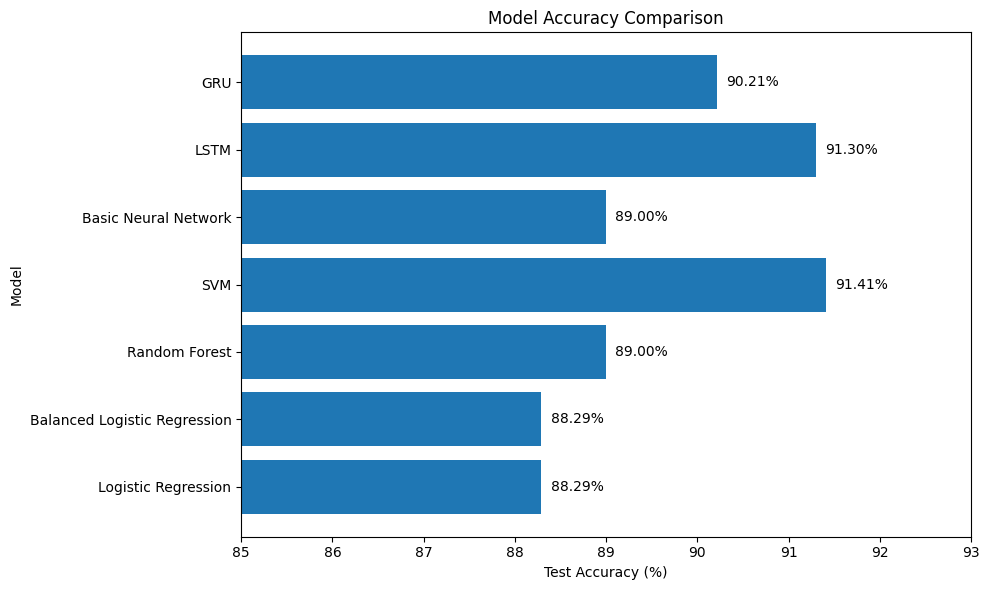

In [39]:
import matplotlib.pyplot as plt

models = [
    "Logistic Regression",
    "Balanced Logistic Regression",
    "Random Forest",
    "SVM",
    "Basic Neural Network",
    "LSTM",
    "GRU"
]

accuracies = [
    88.29,
    88.29,
    89.00,
    91.41,
    89.00,
    91.30,
    90.21
]

plt.figure(figsize=(10, 6))
bars = plt.barh(models, accuracies)

plt.xlabel("Test Accuracy (%)")
plt.ylabel("Model")
plt.title("Model Accuracy Comparison")
plt.xlim(85, 93)

for bar, accuracy in zip(bars, accuracies):
    plt.text(
        bar.get_width() + 0.1,
        bar.get_y() + bar.get_height()/2,
        f"{accuracy:.2f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

### Model Comparison Results

The SVM model had the highest accuracy at 91.41%, followed closely by LSTM at 91.30%. The results show that both machine learning and deep learning models performed well at predicting sentiment from Amazon food reviews.

# Conclusion

This project compared multiple machine learning and deep learning models for sentiment analysis using Amazon food reviews. Traditional machine learning models such as Logistic Regression, Random Forest, and Support Vector Machine were compared alongside deep learning models including a Basic Neural Network, LSTM, and GRU. Comparing multiple approaches helped identify which models performed best while providing hands-on experience with natural language processing and text classification.